# Evolutionary Algorithm - Real-World Semiconductor Workshop Scheduling

In this notebook we will solve a real world scheduling problem using population based **Evolutionary Algorithm**.

## Algorithm

We have our main Evolutionary Algorithm there.
Our main component:
* ...
* ...

In [103]:
import random
from typing import Dict, List, Set, Tuple
import sys
sys.path.append('../data-structure')
from instance_data import InstanceData
from individual import Individual
import numpy as np

class GeneticAlgorithm:
    def __init__(self, instance: InstanceData, seed: int | None = None):
        self.instance = instance
        self.rng = np.random.default_rng(seed)

    def init_population(
        self,
        pop_size: int = 50,
    ) -> List[Individual]:
        """
        Initialize a population of size pop_size.
        """
        population = []
        for _ in range(pop_size):
            # Generating each machine scheduling as empty
            scheduling = [[] for _ in range(self.instance.json_data['m'])]
            for job_id in range(self.instance.json_data['n']):
                # Placing a job where he can be done
                scheduling[random.sample(self.instance.json_data['capable'][job_id], 1)[0]].append(job_id)
            population.append(Individual(scheduling))
        return population

    def evaluate_individual(self, individual: Individual) -> float:
        """
        Returns the makespan of the schedule represented by the individual.
        """
        actual_time = 0.0

        for machine_id, machine_jobs in enumerate(individual.scheduling):
            machine_time = 0.0
            for i, job_id in enumerate(machine_jobs):
                job_release = self.instance.json_data['release'][job_id][machine_id]
                job_duration = self.instance.json_data['duration'][job_id][machine_id]
                job_setup = self.instance.json_data['setup'][machine_jobs[i - 1]][job_id][machine_id] if i > 0 else 0

                # The current machine time is the max betwee the earliest time the job can start
                # AND the time the machine is available after the previous job (if case is applicable)
                # Then we add the job duration to get the time of the machine after the job.
                machine_time = max(job_release, machine_time + job_setup) + job_duration

            actual_time = max(actual_time, machine_time)
        return actual_time


    def evaluate_population(self, population: List[Individual]) -> List[float]:
        """
        Evaluate each individual of the population.
        """
        makespan_scores = []
        for individual in population:
            makespan = self.evaluate_individual(individual)
            makespan_scores.append(makespan)
        return makespan_scores


    def crossover_operator(self, parent1: Individual, parent2: Individual) -> Tuple[Individual, Individual]:
        """
        Crossover operator that takes two parents and produces a child.
        We use a simple one-point crossover for each machine.
        """
        nb_machines = self.instance.json_data['m']

        # Create the 2 offsprings with empty scheduling
        offspring_1: Individual = Individual([[] for _ in range(nb_machines)])
        offspring_2: Individual = Individual([[] for _ in range(nb_machines)])

        # Sets of whats jobs are already assigned to the offsprings
        assigned_offspring_1: Set[int] = set()
        assigned_offspring_2: Set[int] = set()

        for machine_id in range(nb_machines):
            # Take a point for parent 1
            point = random.randint(0, len(parent1.scheduling[machine_id]))

            # All the jobs before the point are assigned to offspring 1, the others to offspring 2
            for job_id in parent1.scheduling[machine_id][:point]:
                offspring_1.scheduling[machine_id].append(job_id)
                assigned_offspring_1.add(job_id)
            for job_id in parent1.scheduling[machine_id][point:]:
                offspring_2.scheduling[machine_id].append(job_id)
                assigned_offspring_2.add(job_id)

        for machine_id in range(nb_machines):
            # All the jobs of parent 2 not in offspring 1 are assigned to it, the others to offspring 2
            for job_id in parent2.scheduling[machine_id]:
                if job_id not in assigned_offspring_1:
                    offspring_1.scheduling[machine_id].append(job_id)
                    assigned_offspring_1.add(job_id)
                if job_id not in assigned_offspring_2:
                    offspring_2.scheduling[machine_id].append(job_id)
                    assigned_offspring_2.add(job_id)
        return offspring_1, offspring_2

    def evolutionary_algorithm(
        self,
        pop_size: int,
        nb_generation: int = 50,
        mu: int = 150,
        lamda: int = 100
    ):
        if pop_size <= 0 or nb_generation <= 0:
            raise ValueError("Population size and number of generations must be positive integers.")

        # Init the population
        pops: List[Individual] = self.init_population(pop_size)

        # The number of generations we want to run the algorithm for and its intial value saved
        generations = nb_generation
        initial_generations = nb_generation

        # We store a progress history to plot the progress of the algorithm
        progress_history = []
        while generations > 0:
            # Evaluate the population
            makespans = self.evaluate_population(pops)


            # The list of offsprings generated by the crossover operator
            offsprings: List[Individual] = []

            j = 0
            while j < lamda:
                parents_chosen_idx = random.choices(range(len(pops)), k=2)
                parents_chosen = [pops[idx] for idx in parents_chosen_idx]

                child1, child2 = self.crossover_operator(parents_chosen[0], parents_chosen[1])

                offsprings.append(child1)
                offsprings.append(child2)
                j += 2

            # We use the strategy (mu + lambda) to select the best individuals for the next generation
            pops: List[Individual] = pops + offsprings
            pops = sorted(pops, key=lambda ind: self.evaluate_individual(ind))[:mu]
            makespans = [self.evaluate_individual(individual) for individual in pops]

            generations -= 1
            current_generation = initial_generations - generations

            best_current = min(makespans)
            progress_history.append((current_generation, best_current))
            print(f"Generation {current_generation} - Best Makespan: {best_current}")

        # Get the best offspring
        best_solution_idx = np.argmin(makespans)
        best_solution = pops[best_solution_idx]
        return best_solution.format_solution(makespans[best_solution_idx]), progress_history

Generation 1 - Best Makespan: 1066
Generation 2 - Best Makespan: 1066
Generation 3 - Best Makespan: 1049
Generation 4 - Best Makespan: 1049
Generation 5 - Best Makespan: 1049
Generation 6 - Best Makespan: 1049
Generation 7 - Best Makespan: 1049
Generation 8 - Best Makespan: 1049
Generation 9 - Best Makespan: 1049
Generation 10 - Best Makespan: 1049
Generation 11 - Best Makespan: 1049
Generation 12 - Best Makespan: 1049
Generation 13 - Best Makespan: 1049
Generation 14 - Best Makespan: 1049
Generation 15 - Best Makespan: 1049
Generation 16 - Best Makespan: 1049
Generation 17 - Best Makespan: 1049
Generation 18 - Best Makespan: 1049
Generation 19 - Best Makespan: 1049
Generation 20 - Best Makespan: 1049
Generation 21 - Best Makespan: 1049
Generation 22 - Best Makespan: 1049
Generation 23 - Best Makespan: 1049
Generation 24 - Best Makespan: 1049
Generation 25 - Best Makespan: 1049
Generation 26 - Best Makespan: 1049
Generation 27 - Best Makespan: 1049
Generation 28 - Best Makespan: 1049
G

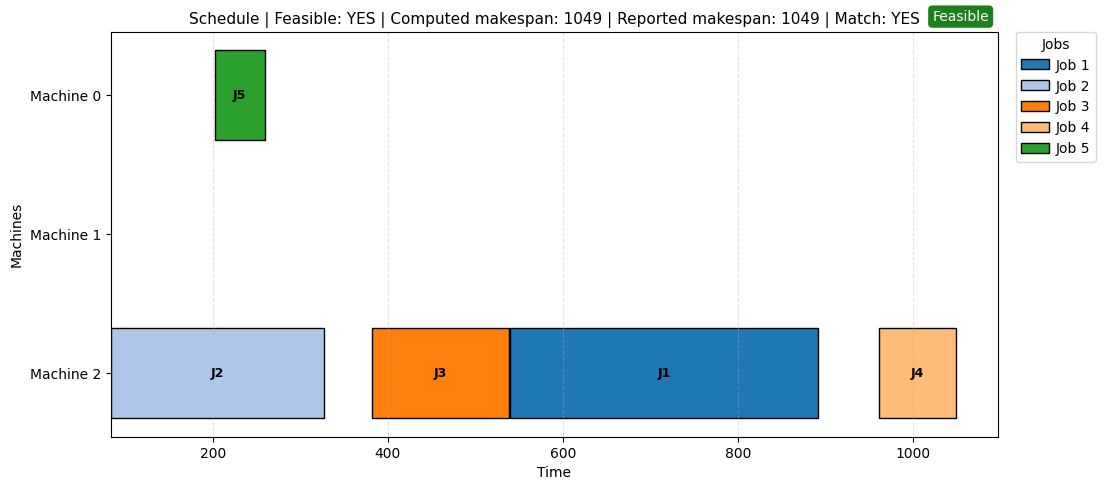

{'feasible': True,
 'checker_result': 1049,
 'reported_makespan': 1049,
 'computed_makespan': 1049}

In [104]:
import sys
sys.path.append('..')
from checker import check_and_evaluate

from scheduler_plot import plot_schedule_from_json

evolutionary_algo = GeneticAlgorithm(instance)
best_solution, progress_history = evolutionary_algo.evolutionary_algorithm(pop_size=50, nb_generation=50, mu=150, lamda=100)

print(f"Best solution found: {best_solution}")
print(check_and_evaluate(instance.json_data, best_solution))

plot_schedule_from_json(instance_path=instance.json_data, solution_path=best_solution)

Generation 1 - Best Makespan: 13612
Generation 2 - Best Makespan: 13612
Generation 3 - Best Makespan: 13612
Generation 4 - Best Makespan: 13612
Generation 5 - Best Makespan: 13612
Generation 6 - Best Makespan: 13212
Generation 7 - Best Makespan: 13212
Generation 8 - Best Makespan: 13212
Generation 9 - Best Makespan: 13212
Generation 10 - Best Makespan: 13212
Generation 11 - Best Makespan: 13212
Generation 12 - Best Makespan: 13212
Generation 13 - Best Makespan: 12891
Generation 14 - Best Makespan: 12891
Generation 15 - Best Makespan: 12891
Generation 16 - Best Makespan: 12891
Generation 17 - Best Makespan: 12891
Generation 18 - Best Makespan: 12891
Generation 19 - Best Makespan: 12721
Generation 20 - Best Makespan: 12721
Generation 21 - Best Makespan: 12721
Generation 22 - Best Makespan: 12721
Generation 23 - Best Makespan: 12721
Generation 24 - Best Makespan: 12721
Generation 25 - Best Makespan: 12721
Generation 26 - Best Makespan: 12721
Generation 27 - Best Makespan: 12721
Generation

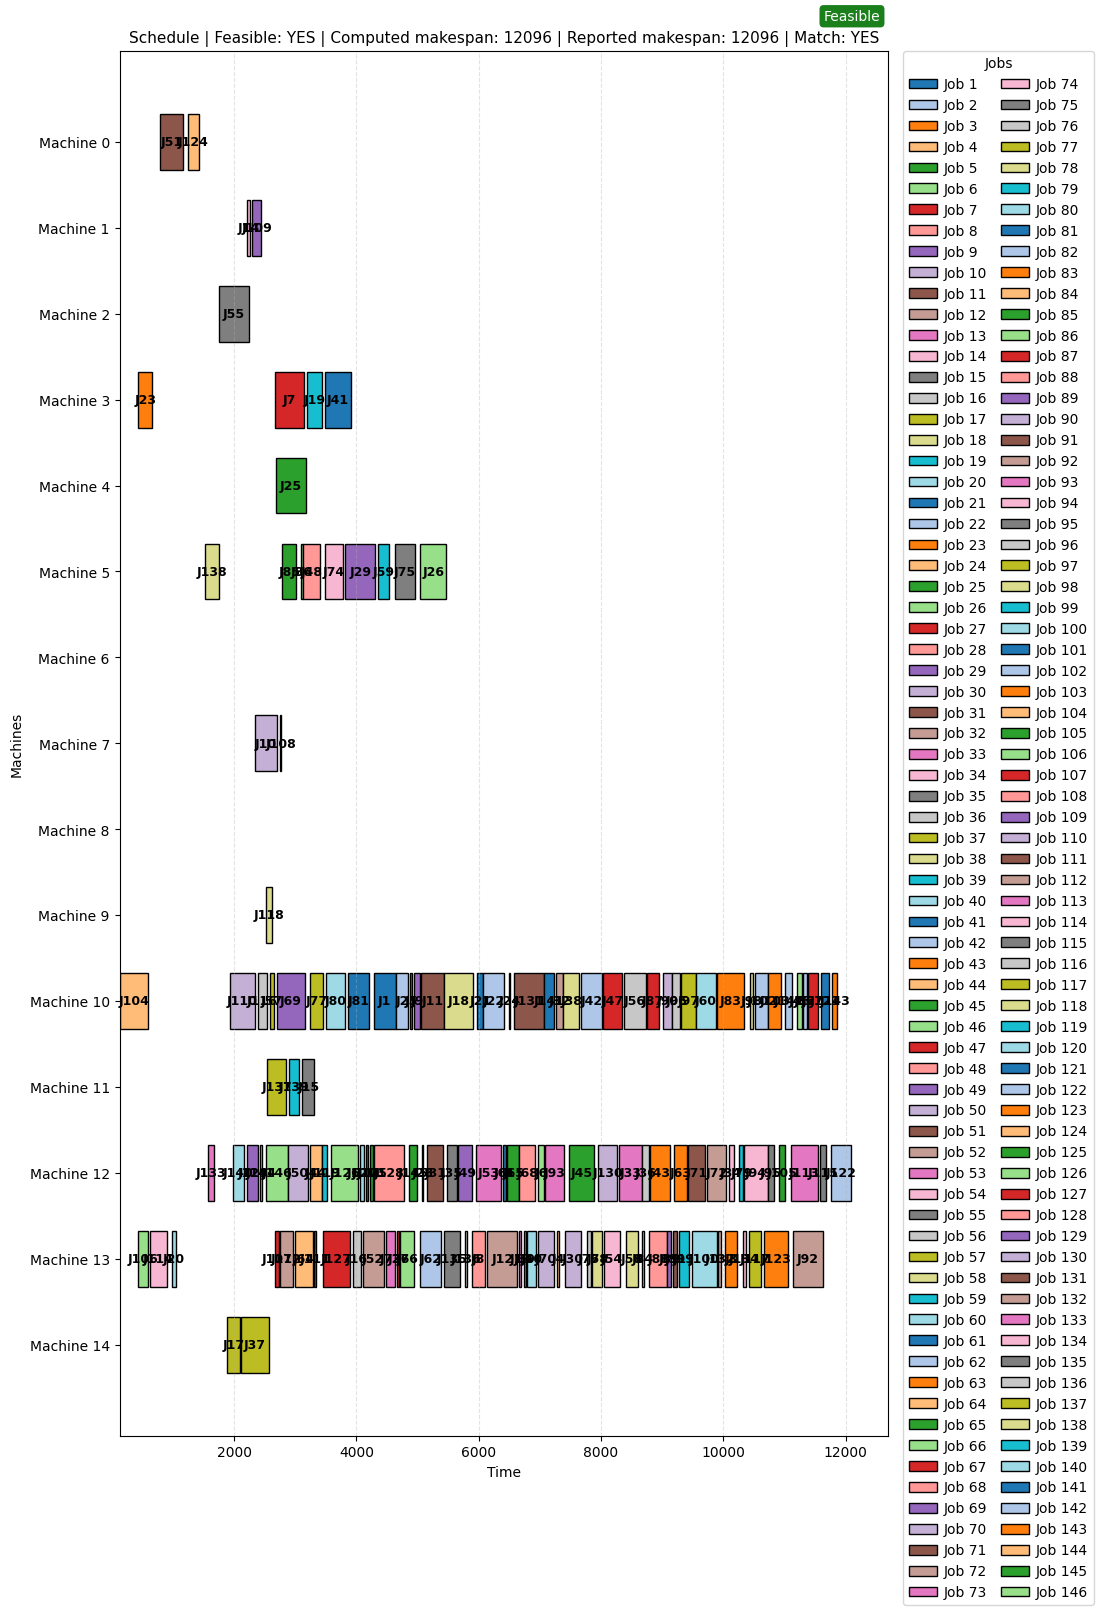

{'feasible': True,
 'checker_result': 12096,
 'reported_makespan': 12096,
 'computed_makespan': 12096}

In [105]:
hard_instance = InstanceData('../examples/357_15_146_H.json')
evolutionary_algo_hard = GeneticAlgorithm(hard_instance)
best_solution_hard, progress_history_hard = evolutionary_algo_hard.evolutionary_algorithm(pop_size=50, nb_generation=50, mu=150, lamda=100)
print(f"Best solution found for hard instance: {best_solution_hard}")
print(check_and_evaluate(hard_instance.json_data, best_solution_hard))

plot_schedule_from_json(instance_path=hard_instance.json_data, solution_path=best_solution_hard)